### Data implementation

In [1]:
import torch 
import os
from torch.utils.data import DataLoader,Dataset
from torchvision import transforms 
from PIL import Image 

In [2]:
class ImageProcessor:
    def __init__(self,root_dir_path,transformations=None):
        self.root_dir_path=root_dir_path
        self.transformations=transformations
        self.all_image_path=[os.path.join(root_dir_path,img) for img in os.listdir(root_dir_path)]

    def __len__(self):
        return len(self.all_image_path)

    def __getitem__(self,idx):
        img_path=self.all_image_path[idx]
        img=Image.open(img_path).convert('RGB')
        if transformations:
            img=self.transformations(img)
        return img 

In [3]:
root_dir_path='./img_align_celeba'
transformations=transforms.Compose([
    transforms.CenterCrop(178),
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),
])

In [4]:
dataset = ImageProcessor(root_dir_path, transformations)
print(f"loaded {len(dataset)} images")
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

loaded 202599 images


### generation network

In [5]:
import torch.nn as nn 
import torch.optim as optim
import numpy as np

In [6]:
class Generator(nn.Module):
    def __init__(self,z_dim=100,img_channels=3):
        super(Generator,self).__init__()
        self.model=nn.Sequential(
            nn.Linear(z_dim,256),
            nn.ReLU(),

            nn.Linear(256,512),
            nn.ReLU(),

            nn.Linear(512,1024),
            nn.ReLU(),

            nn.Linear(1024,64*64*img_channels),
            nn.Tanh(),
            
        )
    def forward(self,z):
        img=self.model(z)
        img=img.view(img.size(0),3,64,64)
        return img

### Discriminator Network

In [7]:
class Discriminator(nn.Module):
    def __init__(self,img_channels=3):
        super(Discriminator,self).__init__()
        self.model=nn.Sequential(
            nn.Flatten(),
            
            nn.Linear(64*64*img_channels,1024),
            nn.LeakyReLU(0.2,inplace=True),

            nn.Linear(1024,512),
            nn.LeakyReLU(0.2,inplace=True),

            nn.Linear(512,256),
            nn.LeakyReLU(0.2,inplace=True),

            nn.Linear(256,1),
            nn.Sigmoid()
            
        )
    def forward(self,img):
        return self.model(img)


In [8]:
GANLoss=nn.BCELoss()
generator=Generator()
g_optimiser=optim.Adam(generator.parameters(),lr=0.0002,betas=(0.5,0.999))
discriminator=Discriminator()
d_optimiser=optim.Adam(discriminator.parameters(),lr=0.0002,betas=(0.5,0.999))

In [9]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


In [10]:
generator=generator.to(device)
discriminator=discriminator.to(device)

### Training GAN

In [11]:
def train(generator,discriminator,dataloader,epochs=10):
    for i, img in enumerate(dataloader):
        real_img = img.to(device)
        batch_size = real_img.size(0)
        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)
        d_optimiser.zero_grad()
        noise = torch.randn(batch_size, 100, device=device)
        fake_img = generator(noise)
        real_loss = GANLoss(
            discriminator(real_img),
            real_labels
        )
        fake_loss = GANLoss(
            discriminator(fake_img.detach()),
            fake_labels
        )
        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        d_optimiser.step()

        g_optimiser.zero_grad()
        g_loss=GANLoss(discriminator(fake_img),real_labels)
        g_loss.backward()
        g_optimiser.step()
    save_generated_images(generator,epochs,device)
    

In [12]:
import matplotlib.pyplot as plt
import torchvision

def save_generated_images(generator, epoch, device, num_imgs=8):
    z = torch.randn(num_imgs, 100).to(device)
    generated_imgs = generator(z).detach().cpu()
    grid = torchvision.utils.make_grid(generated_imgs, nrow=4, normalize=True)
    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.title(f"epoch {epoch+1}")
    plt.axis("off")
    plt.show()

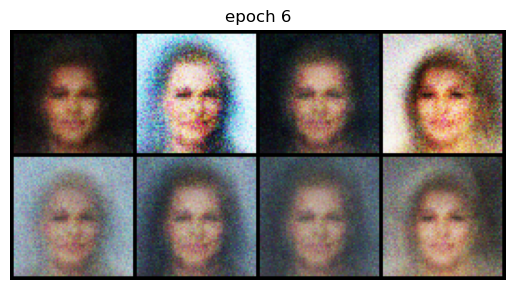

In [13]:
train(generator, discriminator, dataloader, epochs=5)